In [ ]:
# Note:  In the given satellite image band 1 is Blue, band 2 is Green and band 3 is Red

Dimention (bands, Height, Width) of the satellite image is : (1765, 1790)
Number of bands: 5
Coordinate Reference System: EPSG:32643


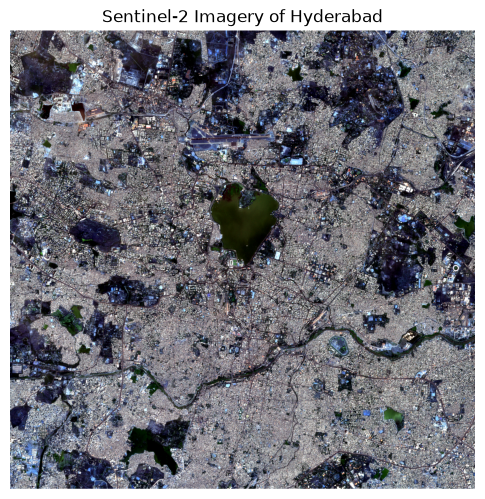

In [1]:
#1
import rasterio
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\aparn\MTech26\crop_merge\HYD_20240207T052026.tif"

with rasterio.open(image_path) as src:
    print(f"Dimention (bands, Height, Width) of the satellite image is : {src.shape}")
    print("Number of bands:", src.count)
    print("Coordinate Reference System:", src.crs)
    blue = src.read(1).astype(float)
    green = src.read(2).astype(float)
    red = src.read(3).astype(float)

def stretch(band):
    p2, p98 = np.percentile(band, (2, 98))
    band = np.clip(band, p2, p98)
    return (band - p2) / (p98 - p2)


red = stretch(red)
green = stretch(green)
blue = stretch(blue)



rgb = np.dstack(( blue, green, red))


plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title("Sentinel-2 Imagery of Hyderabad")
plt.axis("off")
plt.show()

Band Statistics
----------------
Blue (Band 1):
Minimum: 0
Maximum: 65535
Mean: 985.4977872030639

Green (Band 2):
Minimum: 0
Maximum: 65535
Mean: 1227.5103233260006

Red (Band 3):
Minimum: 170
Maximum: 65535
Mean: 1383.6933730039407


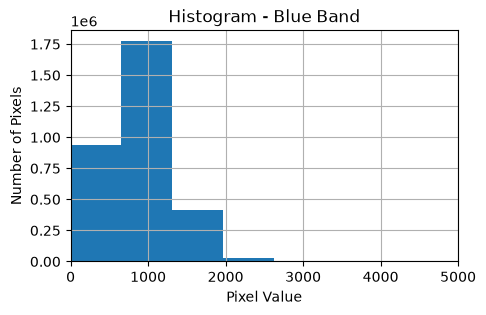

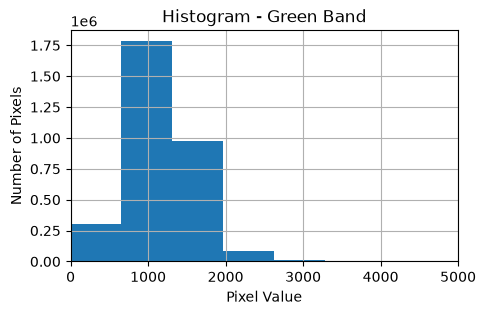

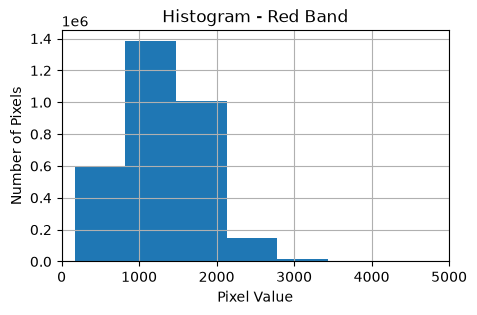

In [15]:
# 2

import rasterio
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\aparn\MTech26\crop_merge\HYD_20240207T052026.tif"

with rasterio.open(image_path) as src:

    blue = src.read(1)
    green = src.read(2)
    red = src.read(3)


print("Band Statistics")
print("----------------")

print("Blue (Band 1):")
print("Minimum:", np.min(blue))
print("Maximum:", np.max(blue))
print("Mean:", np.mean(blue))

print("\nGreen (Band 2):")
print("Minimum:", np.min(green))
print("Maximum:", np.max(green))
print("Mean:", np.mean(green))

print("\nRed (Band 3):")
print("Minimum:", np.min(red))
print("Maximum:", np.max(red))
print("Mean:", np.mean(red))


# 2. Plot histogram for Blue band

plt.figure(figsize=(5, 3))

plt.hist(blue.flatten(), bins=100)

plt.title("Histogram - Blue Band")
plt.xlabel("Pixel Value")
plt.ylabel("Number of Pixels")

# Reduce x-axis range
plt.xlim(0, 5000)

plt.grid()
plt.show()


# 3. Plot histogram for Green band

plt.figure(figsize=(5, 3))

plt.hist(green.flatten(), bins=100)

plt.title("Histogram - Green Band")
plt.xlabel("Pixel Value")
plt.ylabel("Number of Pixels")

# Reduce x-axis range
plt.xlim(0, 5000)

plt.grid()
plt.show()


# 4. Plot histogram for Red band

plt.figure(figsize=(5, 3))

plt.hist(red.flatten(), bins=100)

plt.title("Histogram - Red Band")
plt.xlabel("Pixel Value")
plt.ylabel("Number of Pixels")

# Reduce x-axis range
plt.xlim(0, 5000)

plt.grid()
plt.show()


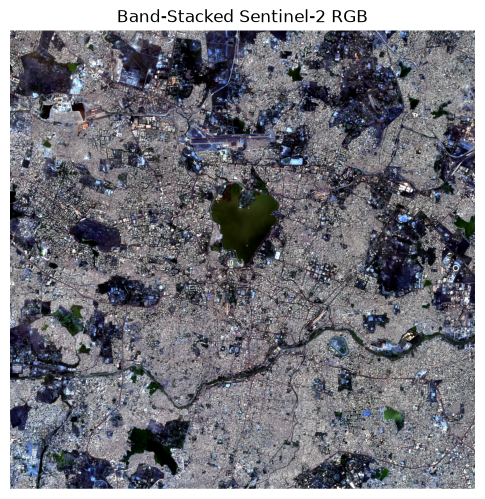

In [3]:
#3
import rasterio
import os

input_path = r"C:\Users\aparn\MTech26\crop_merge\HYD_20240207T052026.tif"

output_path = r"C:\Users\aparn\MTech26\crop_merge\HYD_20240207T052026_bandstack.tif"

with rasterio.open(input_path) as src:

    bands = src.read()

    profile = src.profile.copy()

profile.update(
    count=bands.shape[0],
    driver="GTiff"
)

with rasterio.open(output_path, "w", **profile) as dst:

    dst.write(bands)


with rasterio.open(output_path) as src:

    blue = src.read(1)
    green = src.read(2)
    red = src.read(3)


def stretch(band):
    p2, p98 = np.percentile(band, (2, 98))
    band = np.clip(band, p2, p98)
    return (band - p2) / (p98 - p2)

blue = stretch(blue)
green = stretch(green)
red = stretch(red)

rgb = np.dstack((blue, green, red))

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title("Band-Stacked Sentinel-2 RGB")
plt.axis("off")
plt.show()



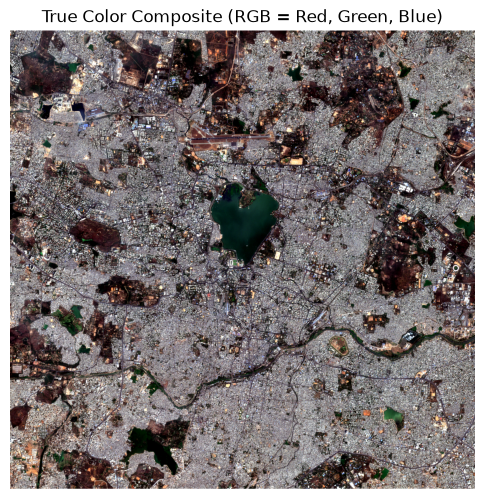

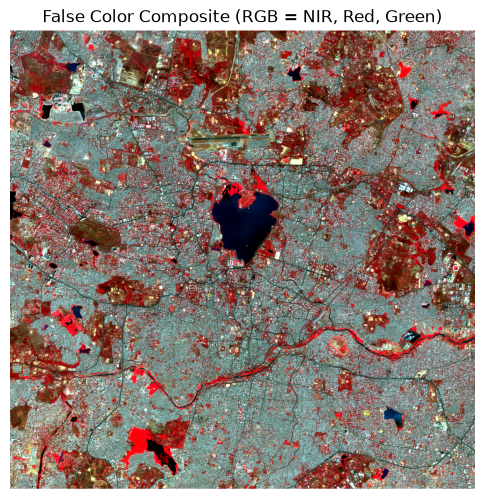

In [4]:
#4
import rasterio
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\aparn\MTech26\crop_merge\HYD_20240207T052026_bandstack.tif"

with rasterio.open(image_path) as src:
    blue = src.read(1)
    green = src.read(2)
    red = src.read(3)
    nir = src.read(4)


def stretch(band):
    p2, p98 = np.percentile(band, (2, 98))
    band = np.clip(band, p2, p98)
    return (band - p2) / (p98 - p2)

blue = stretch(blue)
green = stretch(green)
red = stretch(red)
nir = stretch(nir)

rgb = np.dstack((red, green, blue))

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title("True Color Composite (RGB = Red, Green, Blue)")
plt.axis("off")
plt.show()

fcc = np.dstack((nir, red, green))

plt.figure(figsize=(6, 6))
plt.imshow(fcc)
plt.title("False Color Composite (RGB = NIR, Red, Green)")
plt.axis("off")
plt.show()

Original CRS: EPSG:32643
Clipping completed!
Clipped image size: 630 x 486
Number of bands: 5
CRS: EPSG:32643


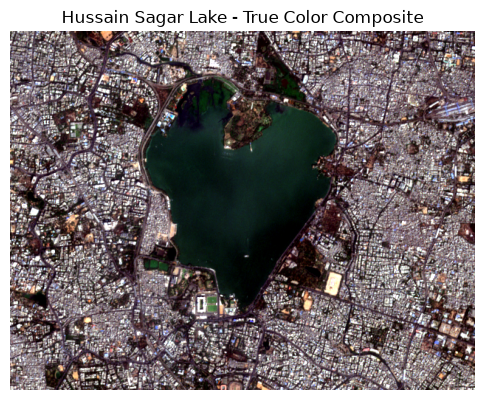

In [5]:
#5
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds

input_path = r"C:\Users\aparn\MTech26\crop_merge\HYD_20240207T052026_bandstack.tif"
output_path = r"C:\Users\aparn\MTech26\crop_merge\lake_clip.tif"

top_left_lon = 78.445526
top_left_lat = 17.442545

bottom_right_lon = 78.503918
bottom_right_lat = 17.399736

# The rectangle boundaries
west  = top_left_lon
north = top_left_lat
east  = bottom_right_lon
south = bottom_right_lat

with rasterio.open(input_path) as src:

    print("Original CRS:", src.crs)

    # Convert coordinates from EPSG:4326
    # to the CRS of the satellite image
    left, bottom, right, top = transform_bounds(
        "EPSG:4326",
        src.crs,
        west,
        south,
        east,
        north
    )

    window = from_bounds(
        left,
        bottom,
        right,
        top,
        src.transform
    )

    clipped = src.read(window=window)

    profile = src.profile.copy()

    profile.update({
        "height": clipped.shape[1],
        "width": clipped.shape[2],
        "transform": src.window_transform(window)
    })

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(clipped)

print("Clipping completed!")

with rasterio.open(output_path) as src:

    print("Clipped image size:", src.width, "x", src.height)
    print("Number of bands:", src.count)
    print("CRS:", src.crs)

    blue = src.read(1).astype(float)
    green = src.read(2).astype(float)
    red = src.read(3).astype(float)


def stretch(band):
    p2, p98 = np.percentile(band, (2, 98))
    band = np.clip(band, p2, p98)
    return (band - p2) / (p98 - p2)

blue = stretch(blue)
green = stretch(green)
red = stretch(red)

rgb = np.dstack((red, green, blue))

plt.figure(figsize=(6, 6))
plt.imshow(rgb)

plt.title("Hussain Sagar Lake - True Color Composite")
plt.axis("off")
plt.show()


Shapefile used:
C:\Users\aparn\MTech26\crop_merge\Sample\Samples.shp

Attribute columns:
Index(['Name', 'geometry'], dtype='str')

Categories present in 'Name' field:
<StringArray>
['urban', 'water', 'builtup', 'vegetation']
Length: 4, dtype: str
CRS: EPSG:32643
Number of bands: 5
Raster size: 1790 x 1765

Shapefile CRS: EPSG:32643

Raster array shape:
(5, 1765, 1790)

Maximum raster value: 65535.0
Reflectance scaling applied: DN / 10000


Processing: Vegetation
Number of ROI polygons: 1

Mean reflectance:
Blue (B2)       (490 nm) : 342.0035
Green (B3)      (560 nm) : 582.3579
Red (B4)        (665 nm) : 482.0596
NIR (B8)        (842 nm) : 2444.0211
SWIR (B11)      (1610 nm) : 1796.0772


Processing: Water
Number of ROI polygons: 1

Mean reflectance:
Blue (B2)       (490 nm) : 492.4837
Green (B3)      (560 nm) : 735.0009
Red (B4)        (665 nm) : 489.7889
NIR (B8)        (842 nm) : 581.0697
SWIR (B11)      (1610 nm) : 140.7344


Processing: Urban
Number of ROI polygons: 1

Mean reflect

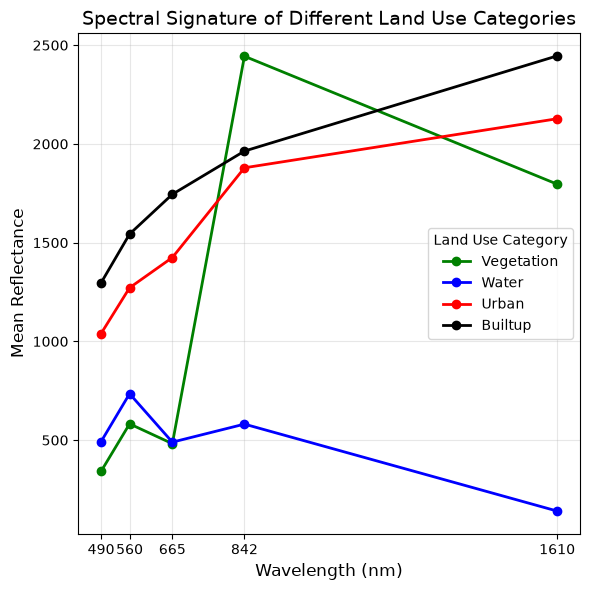

In [6]:
#6

import os
import glob
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.mask import mask

raster_path = r"C:\Users\aparn\MTech26\crop_merge\HYD_20240207T052026.tif"


shapefile_folder = r"C:\Users\aparn\MTech26\crop_merge\Sample"


shapefiles = glob.glob(
    os.path.join(shapefile_folder, "*.shp")
)

if len(shapefiles) == 0:
    raise FileNotFoundError(
        "No .shp file found inside the given folder."
    )

if len(shapefiles) > 1:
    print("Multiple shapefiles found:")
    for shp in shapefiles:
        print(shp)

    print("\nUsing the first shapefile.")

shapefile_path = shapefiles[0]

print("======================================")
print("Shapefile used:")
print(shapefile_path)
print("======================================")

gdf = gpd.read_file(shapefile_path)

print("\nAttribute columns:")
print(gdf.columns)

print("\nCategories present in 'Name' field:")
print(gdf["Name"].unique())

with rasterio.open(raster_path) as src:

    print("CRS:", src.crs)
    print("Number of bands:", src.count)
    print("Raster size:", src.width, "x", src.height)

    print("\nShapefile CRS:", gdf.crs)

    if gdf.crs != src.crs:

        gdf = gdf.to_crs(src.crs)

        print("Shapefile reprojected to raster CRS.")


    image = src.read().astype(float)

    print("\nRaster array shape:")
    print(image.shape)


    # Band 1 → Sentinel-2 B2 → Blue
    # Band 2 → Sentinel-2 B3 → Green
    # Band 3 → Sentinel-2 B4 → Red
    # Band 4 → Sentinel-2 B8 → NIR
    # Band 5 → Sentinel-2 B11 → SWIR

    wavelengths = np.array([
        490,     # Blue
        560,     # Green
        665,     # Red
        842,     # NIR
        1610     # SWIR
    ])

    band_names = [
        "Blue (B2)",
        "Green (B3)",
        "Red (B4)",
        "NIR (B8)",
        "SWIR (B11)"
    ]

    maximum_value = np.nanmax(image)

    print("\nMaximum raster value:", maximum_value)

    if maximum_value > 1:

        image = image / 10000.0

        print("Reflectance scaling applied: DN / 10000")

    else:

        print("Image already appears to be in reflectance.")

    categories = [
        "Vegetation",
        "Water",
        "Urban",
        "Builtup"
    ]

    colors = {
        "Vegetation": "green",
        "Water": "blue",
        "Urban": "red",
        "Builtup": "black"
    }

    spectral_signatures = {}


    for category in categories:

        print("\n")
        print("======================================")
        print("Processing:", category)
        print("======================================")

        category_gdf = gdf[
            gdf["Name"]
            .astype(str)
            .str.strip()
            .str.lower()
            == category.lower()
        ]


        if len(category_gdf) == 0:

            print(
                "WARNING: No ROI found for",
                category
            )

            continue


        print(
            "Number of ROI polygons:",
            len(category_gdf)
        )

        geometries = [
            geom.__geo_interface__
            for geom in category_gdf.geometry
            if geom is not None
        ]


        masked_image, masked_transform = mask(
            src,
            geometries,
            crop=False,
            filled=False
        )


        mean_reflectance = np.ma.mean(
            masked_image,
            axis=(1, 2)
        )


        mean_reflectance = mean_reflectance.filled(
            np.nan
        )

        spectral_signatures[category] = mean_reflectance

        print("\nMean reflectance:")

        for band, wavelength, value in zip(
            band_names,
            wavelengths,
            mean_reflectance
        ):

            print(
                f"{band:15s}"
                f" ({wavelength} nm)"
                f" : {value:.4f}"
            )

print(
    f"{'Category':12s}"
    f"{'Blue':>12s}"
    f"{'Green':>12s}"
    f"{'Red':>12s}"
    f"{'NIR':>12s}"
    f"{'SWIR':>12s}"
)

print("-" * 72)


for category, values in spectral_signatures.items():

    print(
        f"{category:12s}"
        f"{values[0]:12.4f}"
        f"{values[1]:12.4f}"
        f"{values[2]:12.4f}"
        f"{values[3]:12.4f}"
        f"{values[4]:12.4f}"
    )

plt.figure(figsize=(6, 6))


for category, reflectance in spectral_signatures.items():

    plt.plot(
        wavelengths,
        reflectance,
        marker="o",
        linewidth=2,
        color=colors[category],
        label=category
    )


plt.xlabel(
    "Wavelength (nm)",
    fontsize=12
)

plt.ylabel(
    "Mean Reflectance",
    fontsize=12
)

plt.title(
    "Spectral Signature of Different Land Use Categories",
    fontsize=14
)


plt.xticks(wavelengths)

plt.grid(
    True,
    alpha=0.3
)
plt.legend(
    title="Land Use Category"
)

plt.tight_layout()
plt.show()

Image width: 1790
Image height: 1765
CRS: EPSG:32643

NDVI minimum: -0.45118733509234826
NDVI maximum: 0.9027683997299121

Vegetation pixels: 820388
Total pixels: 3159350

Pixel width: 10.0
Pixel height: 10.0
Pixel area: 100.0 square units

----- VEGETATED AREA -----
Vegetated area (m²): 82038800.0
Vegetated area (km²): 82.0388


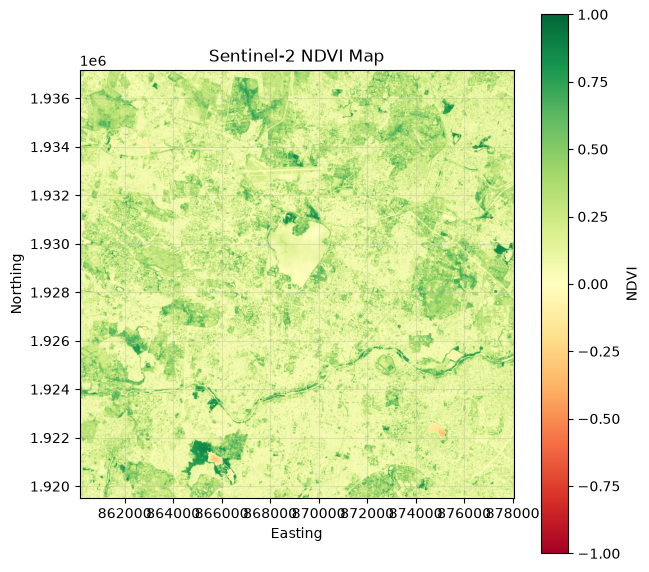

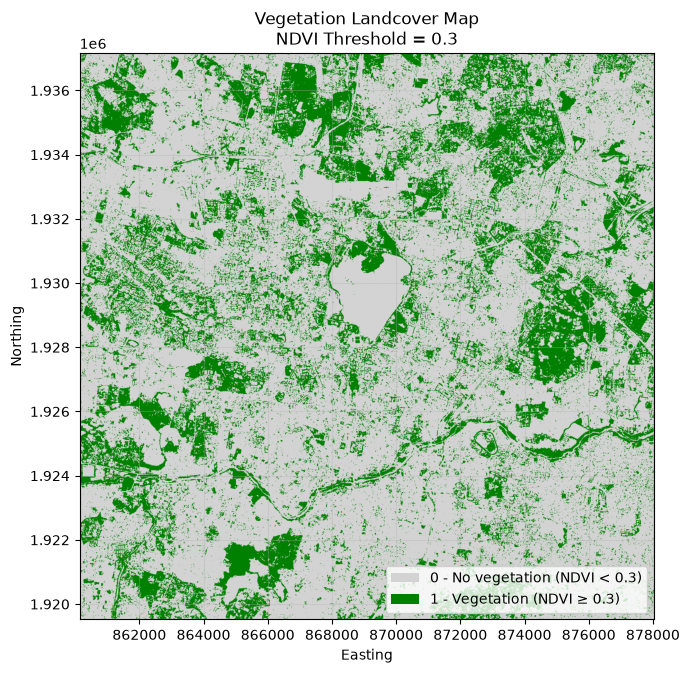

In [7]:
#7
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

file_path = r"C:\Users\aparn\MTech26\crop_merge\HYD_20240207T052026.tif"

with rasterio.open(file_path) as src:

    # Your band order:
    # Band 1 = Blue
    # Band 2 = Green
    # Band 3 = Red
    # Band 4 = NIR
    # Band 5 = SWIR

    red = src.read(3)       # Red
    nir = src.read(4)       # NIR

    # Image information
    transform = src.transform
    crs = src.crs
    width = src.width
    height = src.height

    print("Image width:", width)
    print("Image height:", height)
    print("CRS:", crs)

    if np.nanmax(red) > 1 or np.nanmax(nir) > 1:
        red = red / 10000.0
        nir = nir / 10000.0

    denominator = nir + red

    ndvi = np.where(
        denominator != 0,
        (nir - red) / denominator,
        np.nan
    )

    print("\nNDVI minimum:", np.nanmin(ndvi))
    print("NDVI maximum:", np.nanmax(ndvi))

    threshold = 0.3

    # NDVI < 0.3  → 0 = No vegetation
    # NDVI >= 0.3 → 1 = Vegetation

    vegetation = np.where(
        ndvi < threshold,
        0,
        1
    )

    vegetation_pixels = np.sum(vegetation == 1)
    total_pixels = vegetation.size

    print("\nVegetation pixels:", vegetation_pixels)
    print("Total pixels:", total_pixels)

    pixel_width = abs(transform.a)
    pixel_height = abs(transform.e)

    pixel_area = pixel_width * pixel_height

    print("\nPixel width:", pixel_width)
    print("Pixel height:", pixel_height)
    print("Pixel area:", pixel_area, "square units")

    vegetation_area_m2 = vegetation_pixels * pixel_area

    vegetation_area_km2 = vegetation_area_m2 / 1_000_000

    print("\n----- VEGETATED AREA -----")
    print("Vegetated area (m²):", vegetation_area_m2)
    print("Vegetated area (km²):", vegetation_area_km2)


    extent = plotting_extent(
        vegetation,
        transform
    )


plt.figure(figsize=(7, 7))

plt.imshow(
    ndvi,
    extent=extent,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDVI")

plt.title("Sentinel-2 NDVI Map")

plt.xlabel("Easting")
plt.ylabel("Northing")

plt.grid(True, alpha=0.3)

plt.show()


plt.figure(figsize=(7, 7))

# Two classes:
# 0 = No vegetation
# 1 = Vegetation

cmap = ListedColormap([
    "lightgray",
    "green"
])

norm = BoundaryNorm(
    [-0.5, 0.5, 1.5],
    cmap.N
)

plt.imshow(
    vegetation,
    extent=extent,
    cmap=cmap,
    norm=norm
)

legend_elements = [

    Patch(
        facecolor="lightgray",
        label="0 - No vegetation (NDVI < 0.3)"
    ),

    Patch(
        facecolor="green",
        label="1 - Vegetation (NDVI ≥ 0.3)"
    )
]

plt.legend(
    handles=legend_elements,
    loc="lower right"
)

plt.title(
    "Vegetation Landcover Map\n"
    "NDVI Threshold = 0.3"
)

plt.xlabel("Easting")
plt.ylabel("Northing")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()